<a href="https://colab.research.google.com/github/LeMarque22/auto-mpg-machine-learning/blob/main/TrabalhoMPG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto: Predição de Consumo de Combustível (MPG)

Análise preditiva unindo Redes Neurais e Sistemas de Controle Fuzzy para estimar a eficiência de veículos com base em peso e potência.

In [ ]:
### 1. Carregamento e Inspeção Inicial:
#Importação da base de dados e primeira checagem da saúde das colunas (tipos de variáveis e estatísticas descritivas).
#Setup
import pandas as pd
import numpy as np

# Carregando o dataset
df = pd.read_csv('auto-mpg.csv')

In [ ]:
#Inspeção
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [ ]:
#Limpeza

#Esse é pra trocar o valor "?" por NaN (nulo matématicp do Python).
df['horsepower'] = df['horsepower'].replace('?', np.nan)
#Após limpar o lixp, forçamos o Pandas a converter a coluna inteira pra núm decimal...
df['horsepower'] = df['horsepower'].astype(float)
#Usei a mediana para caso na coluna tiver um carro muito potente, ele poderia 'distorcer a realidade'.
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())

In [ ]:
df.duplicated().sum()
df['car name'].head(10)

,car name
0,chevrolet chevelle malibu
1,buick skylark 320
2,plymouth satellite
3,amc rebel sst
4,ford torino
5,ford galaxie 500
6,chevrolet impala
7,plymouth fury iii
8,pontiac catalina
9,amc ambassador dpl


In [ ]:
df['marca'] = df['car name'].str.split(' ').str[0]
df['modelo'] = df['car name'].str.split(' ').str[1]
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,marca,modelo
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu,chevrolet,chevelle
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320,buick,skylark
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite,plymouth,satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst,amc,rebel
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino,ford,torino


In [ ]:
df['marca'].value_counts()

,count
marca,
ford,51
chevrolet,43
plymouth,31
amc,28
dodge,28
toyota,25
datsun,23
buick,17
pontiac,16


In [ ]:
df['marca'] = df['marca'].replace({
'chevy': 'chevrolet',
'chevroelt': 'chevrolet',
'vokswagen': 'volkswagen',
'vw': 'volkswagen',
'maxda': 'mazda',
'toyouta': 'toyota'
})

<Axes: xlabel='horsepower', ylabel='mpg'>

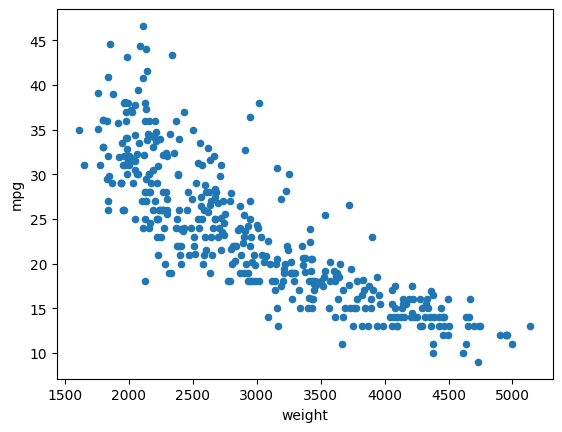

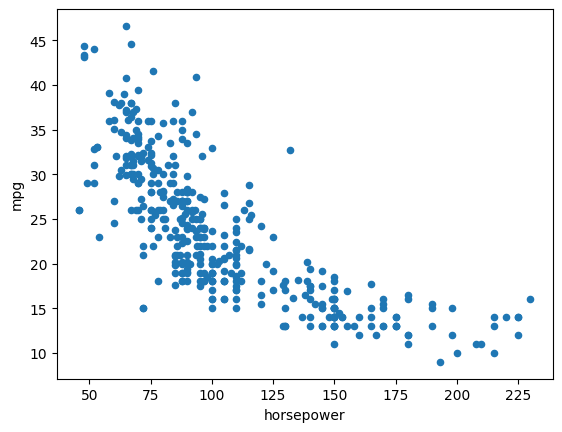

In [ ]:
df.plot.scatter(x='weight', y='mpg')
df.plot.scatter(x='horsepower', y='mpg')

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['weight', 'horsepower']] = scaler.fit_transform(df[['weight', 'horsepower']])
df.head(11)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,marca,modelo
0,18.0,8,307.0,0.456522,0.536150,12.0,70,1,chevrolet chevelle malibu,chevrolet,chevelle
1,15.0,8,350.0,0.646739,0.589736,11.5,70,1,buick skylark 320,buick,skylark
2,18.0,8,318.0,0.565217,0.516870,11.0,70,1,plymouth satellite,plymouth,satellite
3,16.0,8,304.0,0.565217,0.516019,12.0,70,1,amc rebel sst,amc,rebel
4,17.0,8,302.0,0.510870,0.520556,10.5,70,1,ford torino,ford,torino
5,15.0,8,429.0,0.826087,0.773462,10.0,70,1,ford galaxie 500,ford,galaxie
6,14.0,8,454.0,0.945652,0.777148,9.0,70,1,chevrolet impala,chevrolet,impala
7,14.0,8,440.0,0.918478,0.765240,8.5,70,1,plymouth fury iii,plymouth,fury
8,14.0,8,455.0,0.972826,0.797278,10.0,70,1,pontiac catalina,pontiac,catalina
9,15.0,8,390.0,0.782609,0.634250,8.5,70,1,amc ambassador dpl,amc,ambassador


In [ ]:
y = df['mpg']
X = df.drop(columns=['marca', 'car name', 'modelo', 'mpg'])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape

(318, 7)

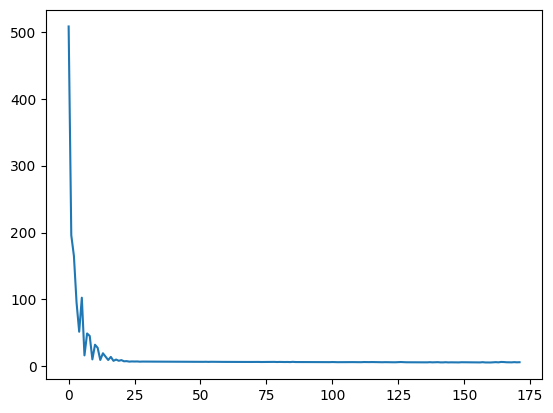

In [ ]:
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

modelo = MLPRegressor(random_state=42, max_iter=1000, hidden_layer_sizes=(50, 50), activation='relu', learning_rate_init=0.01)
modelo.fit(X_train, y_train)
plt.plot(modelo.loss_curve_)
plt.show()



In [ ]:
previsoes = modelo.predict(X_test)
mae = mean_absolute_error(y_test, previsoes)
rmse = np.sqrt(mean_squared_error(y_test, previsoes))

print("Erro Médio Absoluto (MAE):", mae)
print("Raiz do Erro Quadrático Médio (RMSE):", rmse)

modelo.score(X_test, y_test)

Erro Médio Absoluto (MAE): 2.173251341315625
Raiz do Erro Quadrático Médio (RMSE): 2.8599967633985117


0.8478682814752843

In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 25.4 MB/s eta 0:00:00


O consumo calculado (MPG) é: 17.58064516129034


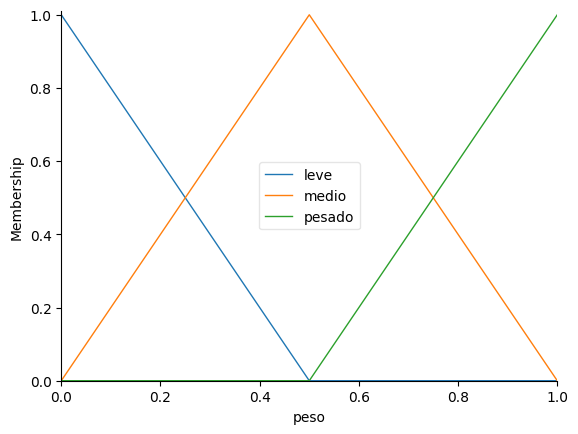

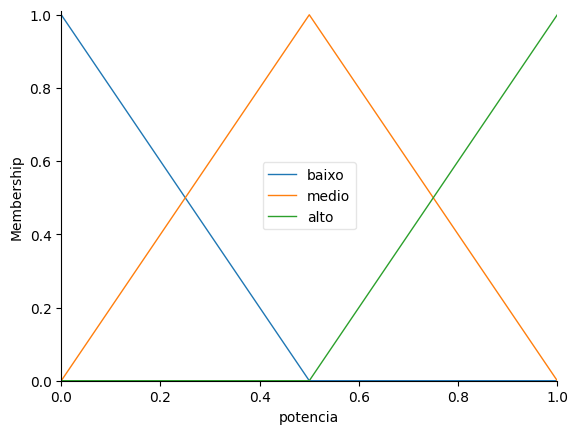

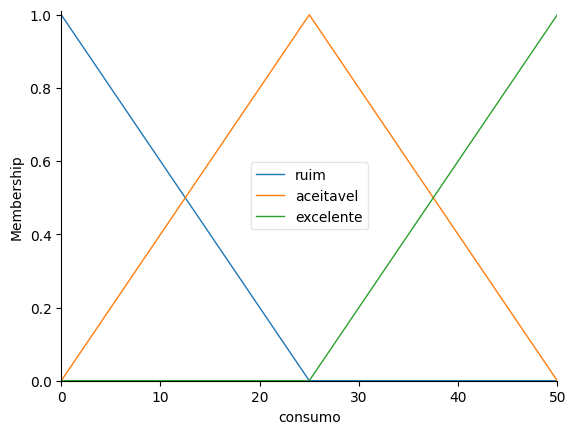

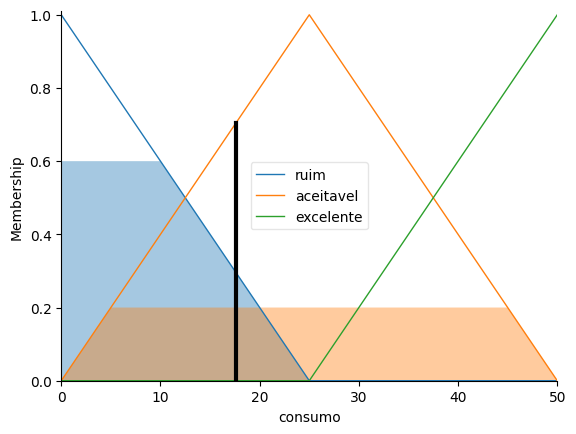

In [ ]:
from skfuzzy import control as ctrl
import numpy as np

peso = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'peso')
potencia = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'potencia')
consumo = ctrl.Consequent(np.arange(0, 51, 1), 'consumo')

peso.automf(names=['leve', 'medio', 'pesado'])
potencia.automf(names=['baixo', 'medio', 'alto'])
consumo.automf(names=['ruim', 'aceitavel', 'excelente'])

peso.view()
potencia.view()
consumo.view()

regra1 = ctrl.Rule(peso['leve'] & potencia['baixo'], consumo['excelente'])
regra2 = ctrl.Rule(peso['medio']& potencia['medio'], consumo['aceitavel'])
regra3 = ctrl.Rule(peso['pesado']& potencia['alto'], consumo['ruim'])

sistema_controle = ctrl.ControlSystem([regra1, regra2, regra3])
simulador = ctrl.ControlSystemSimulation(sistema_controle)

simulador.input['peso'] = 0.8
simulador.input['potencia'] = 0.9
simulador.compute()
print("O consumo calculado (MPG) é:", simulador.output['consumo'])
consumo.view(sim=simulador)

# Diário de bordo pessoal sobre o projeto:

Após usar o método para limpar os dados, sobretudo na coluna "horsepower", notei que ao invés de 398 valores, ele me retornou 392, ou seja, 6 valores que estvam com o caracter "?"... Portanto, são 6 buracos vazios (NaN)

Em seguida, precisei tampar esse buracos, através de pesquisas, achei duas opções: média e mediana. A média iria pegar todos os valores, somar e dividir, o problema é que se tivermos carros esportivos muito potentes na base, a média vai subir muito e 'distorcer a realidade'. Já a mediana seria a minha escolha perfeita, pois mesmo se tiver superesportivos na coluna, o Pandas vai colocar todos numa fila por ordem de potência e escolher exatamente por valor do carro qeu está no meio, ou seja, se houver um com valores mais altos que o normal, a medianacontinuará normal. ela revela a realidade e ignora os extremos.

O próximo passo foi localizar duplicatas na nossa base, usei o método .duplicate() para caçar dados idênticos na tabela inteira e depois a ação .sum() para somar todos os valores de True (Que vale 1) e me retornar quantas duplicatas vieram. Nesse caso, não teve nenhuma...

Enfim, após isso, tive que extrair a marca dos veículos da coluna car name. O que eu fiz para isso, eu tive que estrutrar uma linha de montagem através do código. Muito bem, precisei criar uma nova coluna, chamada "marca", depois usei o dataframe da "car name" para pegar os dados brutos dalí pra nossa coluna recém-nascida. Em seguida, aprendi que o Pandas foi feito para tratar com números complexos, por isso, foi necessário por uma ação de .str pra ele parar de tratar a coluna car name como números e tratar como texto. Depois, a ação split serviu para separar a frase inteira, e o que eu queria separar? o nome da marca! Por isso o str[0]. Pelo o que entendi com isso tudo é o que se chama "Engenharia de Atributos (Features Engineering). "É o ato de criar uma informação útil a partir de um dado cru.", de acordo com o Gemini.

A última da noite eu tive que localizar erros de digitação na base. Então fiz um comando que agruparia todas as marcas igualmente, contar quantas vezes elas apareceram e me retornar a soma de todas. assim, os erros de digitação que aparecem poucas vezes vão sempre estar no final da lista. Depois de detectar todas as palavras erradasd, eu tive que juntar elas, seja com erros de digitação ou apelidos com a ação value_counts(), ele me mostra todas as linhas contadinhas com os nomes, isto é, apareceram 51 linhas com o nome 'Ford' e 1 linha com o nome 'Maxda'.
Para corrigir esse problema, bastou eu fazer uma grande substituição através da ação .replace(), só que ao invés de ser só uma, troquei várias ao mesmo tempo com o uso de chaves.

Muito bem, o próximo passo, eu tive que fazer gráficos estatistico da relação de peso e potencia dos nossos veículos e o decréscimo de sua eficiência (MPG)
Primeiro tive que escrver a Lógica do Gráfico de Dispersão usando ações de ".plot" e "scatter()". Aparentemente o plot serve para desenhar, equanto o scatter me traz aquele gráfico de pontinhos espalhados.
Bom, no primeiro gráfico mostra de ordem crescente lá em baixo os pesos de 1500 a 5000, enquanto no MPG temos 10 a 45 (Deve estar o sistemas de medidas imperiais, eu imagino). Notei que há uma curva lá no 45 de uso de milhas, iniciando-se lá no topo, junto dos carros de 2000 a 2500. Depois ele começa a descer. Os mais pesados, de 3000 a 5000 atingem de 20 a 10 MPG em média...
Já o segundo gráfico foi bem curioso... Notei que os carros de 50 cavalos são os únicos que mantém uma média de 45 mpg ou mais. É de se notar, também que, carros de 50 a 125 mantém uma média de 15 a 35 mpg, enquanto a maior concontração dos carros da nossa base fica 75 a 100 cavalos. Os carros com mais de 200 cavalos obviamente possuem um uso médio de 10 a 15. Alguns estourando quase chegando ao 20.  

Agora para finalizar essa primeira etapa, tive que fazer o escalacionamento. Ela não poderia olhar o peso e e a potência do jeito que está. Como a IA é matemática pura, ela pode olhar para os valores mais altos como o peso e achar que o maior valor é infinitamente mais importante que a potÊncia...
Tive que aprender uma nova biblioteca do Pandas para mascarar essa diferençaa de grandeza (Libras vs Cavalos). Mas como? Bom, aí entra o escalonamento. Ele pega essas duas tabelas e espreme dentro régua (Valores de 0 a 1). O carro mais pesado vira o número 1.0, o mais leve vira 0.0, e os outros ficam nos decimais (0.5, 0.7...). O mesmo acontece com a potência. Assim, a IA compara banana com banana
O quebra cabeça pra isso foi pegar a biblioteca sklearn, depois processing e mais outros rolês.. Cansei nesse momento, de verdade mesmo. Enfimm: Okay, vi bem que os valores dos cavalos e peso estão de 0.0 a 1.0 (Pontiac Catalina com 0.97 de potência com o peso de 0.79.) Temos um vencedor? haha Enfim, muito legal analisar dados assim.




Entrando na Etapa 2, a primeira coisa que precisei fazer foi separar as pistas do gabarito para a máquina não trapacear. Criei uma variável y para guardar só a coluna 'mpg' (o gabarito). Depois, criei um X (as pistas) usando a ação .drop() para jogar fora o próprio mpg e todas as colunas de texto (marca, nome, modelo), já que redes neurais dão erro fatal se tentarem ler letras.

Com as pastas separadas, usei a ferramenta train_test_split do sklearn para fatiar os dados. A regra de mercado é 80/20: 80% das linhas (318 carros) ficaram no X_train para a IA estudar, e 20% (80 carros) foram trancados no cofre do X_test para a prova final. Ah, e usei o random_state=42 para travar o embaralhador, assim o resultado não fica mudando toda vez que eu rodar o código.

Por fim, dei vida à IA usando o MLPRegressor. Liguei a máquina limitando a 1000 tentativas (max_iter=1000) para ela não desistir rápido no meio dos cálculos. Usei a ação .fit(X_train, y_train) para o aluno sentar e estudar o material. Depois que ela encontrou os padrões matemáticos sozinha, mandei ela fazer a prova com .predict(X_test) chutando as respostas dos carros que ela nunca tinha visto. O resultado final? Usei o .score() para o professor corrigir e a máquina me retornou 0.8551. Ou seja, minha IA recém-nascida tirou nota 85,5 na prova final! Que ótimo aluno você é robôzinho hihihi

Entrando na Etapa 3 e reta final do projeto, meu desafio foi ensinar a máquina a ter 'bom senso' usando a Lógica Fuzzy. Em vez do computador pensar de forma rígida em 0 ou 1 (falso ou verdadeiro), a lógica fuzzy ensina a máquina a entender os tons de cinza, como um carro ser 'um pouco' pesado ou 'muito' potente.

Primeiro, tive que importar a biblioteca scikit-fuzzy e usar o numpy para criar as réguas matemáticas (o universo do nosso problema). O peso e a potência ficaram numa régua espremida de 0 a 1, e o nosso gabarito, o consumo (MPG), numa régua de 0 a 51. Configurei o peso e a potência como 'Antecedentes' (Causas) e o consumo como 'Consequente' (Efeito).

OV lacne aconteceu com a ação .automf(). Em vez de calcular a geometria na mão, essa ferramenta fatiou automaticamente minhas réguas em três categorias perfeitas (leve/medio/pesado, baixo/medio/alto e ruim/aceitavel/excelente) e gerou gráficos irados com triângulos se cruzando. Deu pra ver exatamente onde o computador começa a ter dúvidas se um carro é leve ou médio!

Depois, precisei virar uma especiie de roterista e escrever as regras do jogo. A estrutura foi literalmente traduzir o pensamento humano para o código através do ctrl.Rule(). Juntei as pistas com o 'E' comercial (&). Por exemplo: SE o peso for pesado & a potência for alta, ENTÃO o consumo é ruim. Isso foi mole, pra falar a verdade.

Por fim, empacotei essas regras num ControlSystem e liguei o motor da IA criando um ControlSystemSimulation. Esse foi o juiz da nossa brincadeira. Na hora de testar na prática, joguei os dados de um carro super pesado (0.8) e potente (0.9) nas gavetas do simulador e ele me retornou um consumo péssimo de 17.5 MPG. Para tirar a prova real, testei um carro super leve e fraco (0.2 e 0.2), e o consumo saltou para quase 30 MPG! A máquina não apenas aprendeu a matemática bruta lá na Etapa 2, como agora sabe interpretar a realidade através de palavras.